# **Carregamento dos Dados**

In [77]:
!pip install xgboost lightgbm shap lime pandas scikit-learn matplotlib seaborn kagglehub lifelines

# Importa a biblioteca inicial
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Biblioteca de Machine Learning e Seleção/Redução de Atributos
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
import joblib

# Biblioteca de Avaliação de Métrica e Estatística
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score, classification_report, roc_curve
from sklearn.model_selection import cross_val_score
from scipy.stats import kendalltau

# Biblioteca de Interpretabilidade e Explicação Agnóstica
import shap
import lime
from lime import lime_tabular
from lifelines.utils import concordance_index

# Configura o estilo do gráfico para o relatório científico
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.dpi'] = 100

In [78]:
# Baixa o dataset oficial
path = kagglehub.dataset_download("amandam1/colorectal-cancer-patients")
csv_files = glob.glob(os.path.join(path, "*.csv"))
if not csv_files:
    raise FileNotFoundError("Nenhum arquivo CSV encontrado.")
dataset_path = csv_files[0]
print("Dataset pronto para o pipeline:", dataset_path)

Using Colab cache for faster access to the 'colorectal-cancer-patients' dataset.
Dataset pronto para o pipeline: /kaggle/input/colorectal-cancer-patients/Colorectal Cancer Patient Data.csv


In [79]:
# 1. Carregamento do dado
df = pd.read_csv(dataset_path)
display(df.head())

,Unnamed: 0,ID_REF,Age (in years),Dukes Stage,Gender,Location,DFS (in months),DFS event,Adj_Radio,Adj_Chem
0,0,GSM877126,62.0,A,Male,Left,108.0,0.0,1.0,0.0
1,1,GSM877127,77.0,B,Male,Left,40.0,1.0,1.0,0.0
2,2,GSM877128,66.0,C,Female,Left,49.0,0.0,1.0,0.0
3,3,GSM877129,72.0,D,Female,Left,45.0,0.0,1.0,1.0
4,4,GSM877130,75.0,C,Male,Left,40.0,0.0,0.0,1.0


**ID_REF** - ID do Paciente.

**Age (in years)** - Idade do paciente no diagnóstico

**Dukes Stage** - Estágio do câncer de acordo com a classificação Dukes (A, B, C, D)

**Gender** - Sexo do Paciente

**Location** - Localização do Tumor (Left, Right, Colon, Rectum).

**DFS (months)** - sobrevida livre da doença.

**DFS event**- Evento de sobrevivência (alvo: 1 = recorrência ou morte, 0 = sem recorrência).

**Adj_Radio** - Receita de radioterapia (1 = recebeu, 0 = não recebeu).

**Adj_Chem** - Receita de quimioterapia (1 = recebeu, 0 = não recebeu).

# **Análise e Tratamento dos Dados**

In [80]:
# Informação do Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       63 non-null     int64  
 1   ID_REF           62 non-null     object 
 2   Age (in years)   62 non-null     float64
 3   Dukes Stage      62 non-null     object 
 4   Gender           62 non-null     object 
 5   Location         62 non-null     object 
 6   DFS (in months)  62 non-null     float64
 7   DFS event        62 non-null     float64
 8   Adj_Radio        62 non-null     float64
 9   Adj_Chem         62 non-null     float64
dtypes: float64(5), int64(1), object(4)
memory usage: 5.1+ KB


In [81]:
# Verifica valor nulo
df.isnull().sum()

,0
Unnamed: 0,0
ID_REF,1
Age (in years),1
Dukes Stage,1
Gender,1
Location,1
DFS (in months),1
DFS event,1
Adj_Radio,1
Adj_Chem,1


In [82]:
# Remove valor ausente
df.dropna(inplace=True)
print(f"df após remoção de NaNs: {df.shape[0]} linhas")

df após remoção de NaNs: 62 linhas


In [83]:
# Verifica duplicado
duplicados = df.duplicated().sum()
print(f"Número de linha duplicada: {duplicados}\n")

Número de linha duplicada: 0



=== FASE DE ANÁLISE EXPLORATÓRIA ===

Proporção do Evento de Sobrevida (DFS event):
 - Status 1.0 (Recorrência / Óbito (Falha)): 37 paciente (59.68%) 
 - Status 0.0 (Censurado (Vivo / Saída)): 25 paciente (40.32%) 


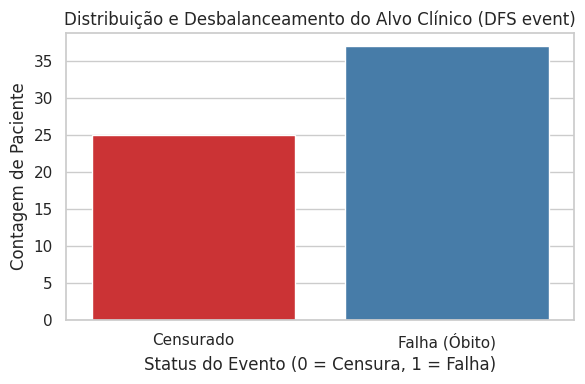

In [84]:
print(f"=== FASE DE ANÁLISE EXPLORATÓRIA ===")

# 1. Análise de Desbalanceamento do Alvo Clínico
contagem_eventos = df['DFS event'].value_counts()
proporcoes_eventos = df['DFS event'].value_counts(normalize=True) * 100
print("\nProporção do Evento de Sobrevida (DFS event):")
for classe, qtd in contagem_eventos.items():
    status_nome = "Recorrência / Óbito (Falha)" if classe == 1.0 else "Censurado (Vivo / Saída)"
    print(f" - Status {classe} ({status_nome}): {qtd} paciente ({proporcoes_eventos[classe]:.2f}%) ")

# Gráfico 1: Desbalanceamento
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='DFS event', palette="Set1", hue='DFS event', legend=False)
plt.title("Distribuição e Desbalanceamento do Alvo Clínico (DFS event)")
plt.xlabel("Status do Evento (0 = Censura, 1 = Falha)")
plt.ylabel("Contagem de Paciente")
plt.xticks(ticks=[0, 1], labels=["Censurado", "Falha (Óbito)"])
plt.tight_layout()
plt.show()

In [85]:
print(f"=== MÓDULO DE PRÉ-PROCESSAMENTO ===")

df_clean = df.copy()

# 1. Remoção de coluna irrelevante
colunas_irrelevantes = ['Unnamed: 0', 'ID_REF']
df_clean.drop(columns=[col for col in colunas_irrelevantes if col in df_clean.columns], errors='ignore', inplace=True)

# 2. Tratamento de Outlier na Idade
idade = 'Age (in years)'
Q1 = df_clean[idade].quantile(0.25)
Q3 = df_clean[idade].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
df_clean[idade] = np.clip(df_clean[idade], limite_inferior, limite_superior)

# 3. Transformação Ordinal do Dukes Stage (A=0, B=1, C=2, D=3)
le_dukes = LabelEncoder()
df_clean['Dukes Stage'] = le_dukes.fit_transform(df_clean['Dukes Stage'])
print("-> 'Dukes Stage' convertido para escala numérica (Ordinal Encoding).")

# 4. Feature Engineering: Estratégia Adjuvante
def calcular_estrategia(row):
    if row['Adj_Radio'] == 1.0 and row['Adj_Chem'] == 1.0: return 'Both_Therapies'
    elif row['Adj_Radio'] == 1.0: return 'Radio_Only'
    elif row['Adj_Chem'] == 1.0: return 'Chem_Only'
    else: return 'No_Treatment'

df_clean['Adjuvant_Strategy'] = df_clean.apply(calcular_estrategia, axis=1)
df_clean.drop(columns=['Adj_Radio', 'Adj_Chem'], errors='ignore', inplace=True)
print("-> Pipeline de pré-processamento concluído.")

=== MÓDULO DE PRÉ-PROCESSAMENTO ===
-> 'Dukes Stage' convertido para escala numérica (Ordinal Encoding).
-> Pipeline de pré-processamento concluído.


In [64]:
df_clean
df_clean.dropna(inplace=True)
print(f"df_clean após remoção de NaNs: {df_clean.shape[0]} linhas")

df_clean após remoção de NaNs: 62 linhas


In [91]:
print(f"=== CODIFICAÇÃO, NORMALIZAÇÃO E REDUÇÃO (PCA) ===")

X_raw = df_clean.drop(columns=['DFS (in months)', 'DFS event'], errors='ignore').copy()
y_time = df_clean['DFS (in months)']
y_event = df_clean['DFS event']

# O Dukes Stage agora é tratado como atributo numérico/ordinal
num_features = ['Age (in years)', 'Dukes Stage']
cat_features = ['Gender', 'Location', 'Adjuvant_Strategy']

# One-Hot Encoding para atributo nominal
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
encoded_matrix = encoder.fit_transform(X_raw[cat_features])
df_encoded = pd.DataFrame(encoded_matrix, columns=encoder.get_feature_names_out(cat_features), index=X_raw.index)

# StandardScaler para atributo numérico e ordinal
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(X_raw[num_features]), columns=num_features, index=X_raw.index)

X_integrated = pd.concat([df_scaled, df_encoded], axis=1)

# PCA para redução de dimensionalidade
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_integrated)

print(f"-> Dimensão integrada: {X_integrated.shape[1]}")
print(f"-> Componente do PCA: {pca.n_components_}")
display(X_integrated.head())

=== CODIFICAÇÃO, NORMALIZAÇÃO E REDUÇÃO (PCA) ===
-> Dimensão integrada: 9
-> Componente do PCA: 7


,Age (in years),Dukes Stage,Gender_Male,Location_Left,Location_Rectum,Location_Right,Adjuvant_Strategy_Chem_Only,Adjuvant_Strategy_No_Treatment,Adjuvant_Strategy_Radio_Only
0,0.075801,-1.353116,1.0,1.0,0.0,0.0,0.0,0.0,1.0
1,1.764309,-0.420969,1.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.526070,0.511177,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,1.201473,1.443323,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,1.539175,0.511177,1.0,1.0,0.0,0.0,1.0,0.0,0.0


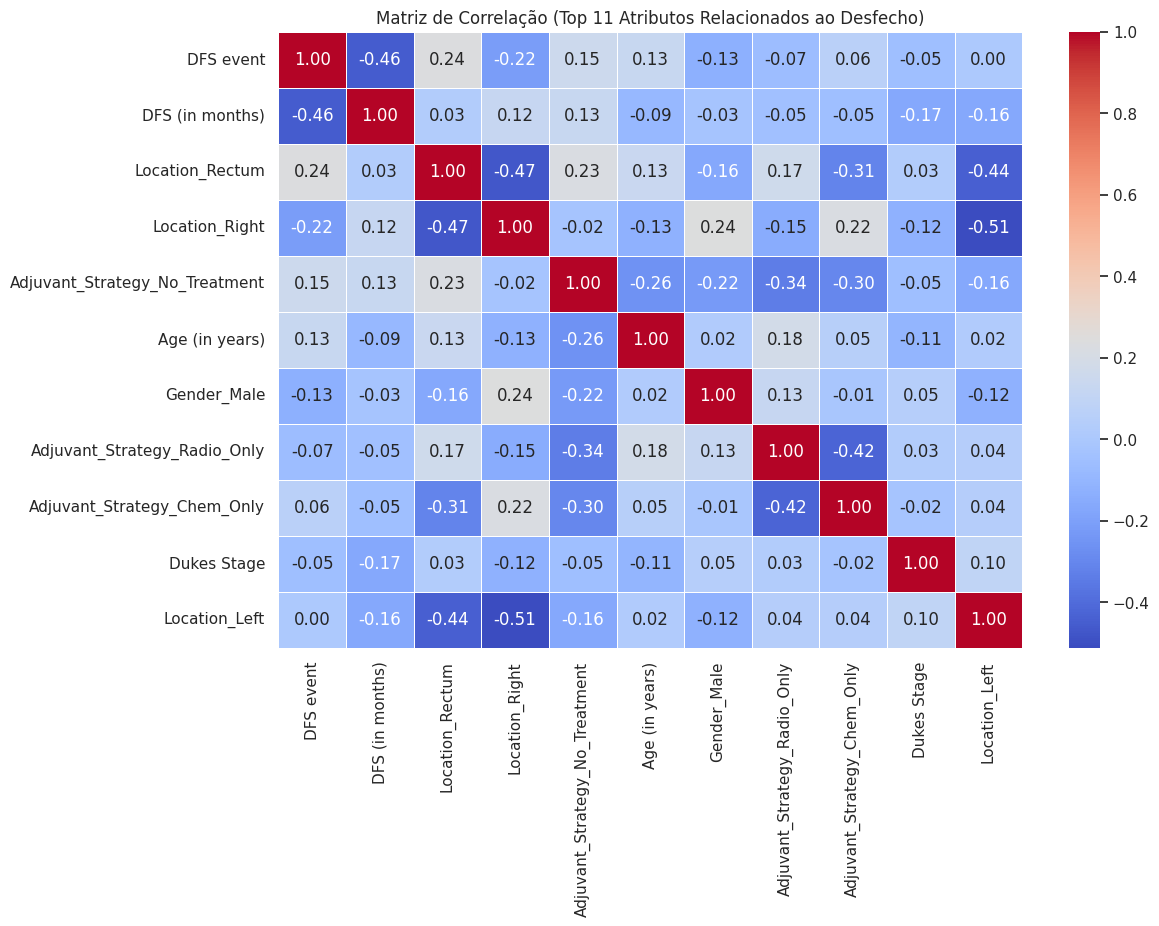

In [66]:
# Gráfico de Matriz de Correlação das Features mais relevantes com o desfecho

# Define target column names
time_col = 'DFS (in months)'
event_col = 'DFS event'

# Reconstruct df_treated from processed features and target variables
df_treated = pd.concat([X_integrated, y_time, y_event], axis=1)

plt.figure(figsize=(12, 8))
correlation_matrix = df_treated.corr()

# Filtrando as top correlações com a variável de evento para não poluir o gráfico
# Ensure event_col is in the correlation matrix
if event_col in correlation_matrix.columns:
    top_corr_features = correlation_matrix[event_col].abs().sort_values(ascending=False).head(15).index
    sns.heatmap(df_treated[top_corr_features].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title("Matriz de Correlação (Top 11 Atributos Relacionados ao Desfecho)")
else:
    print(f"Column '{event_col}' not found in the correlation matrix. Cannot plot top correlated features.")
plt.show()

In [86]:
# 1. Divisão do dado - Mantém a estratificação para preservar a proporção de evento
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_integrated, y_event, test_size=0.3, random_state=42, stratify=y_event
)

# Cálculo do peso para balanceamento da classe positiva (Recorrência)
pos_weight = (y_train_c == 0).sum() / (y_train_c == 1).sum()

# 2. Preparação do alvo de Sobrevivência (Formato especial para XGBoost Survival)
y_survival_train = y_time.loc[y_train_c.index].copy()
y_survival_train[y_train_c == 0] = -y_survival_train[y_train_c == 0] # Negativo indica censura

# 3. Definição Unificada do Modelo
model_xgb_survival = xgb.XGBRegressor(objective='survival:cox', eval_metric='cox-nloglik', random_state=42)
model_xgb_c = xgb.XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=pos_weight)
model_lgb_c = lgb.LGBMClassifier(is_unbalance=True, random_state=42, importance_type='gain', verbose=-1)
model_rf_c = RandomForestClassifier(class_weight='balanced_subsample', random_state=42, n_estimators=100)

# 4. Execução do Treinamento
print('=== Treinando Modelo (Survival e Classificação) ===')
model_xgb_survival.fit(X_train_c, y_survival_train)
model_xgb_c.fit(X_train_c, y_train_c)
model_lgb_c.fit(X_train_c, y_train_c)
model_rf_c.fit(X_train_c, y_train_c)

print(f'-> Peso de balanceamento aplicado: {pos_weight:.2f}')
print('-> Todo o modelo (XGB Survival, XGB/LGBM/RF Classification) treinado com sucesso.')

=== Treinando Modelo (Survival e Classificação) ===
-> Peso de balanceamento aplicado: 0.65
-> Todo o modelo (XGB Survival, XGB/LGBM/RF Classification) treinado com sucesso.


In [92]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

# Define o modelo de classificação para a verificação de inversão
modelos_c_for_inversion_check = {
    'XGBoost': model_xgb_c,
    'LightGBM': model_lgb_c,
    'Random Forest': model_rf_c
}

# Determina o status de inversão para cada modelo
is_inverted_status = {}
for name, model in modelos_c_for_inversion_check.items():
    probs_for_check = model.predict_proba(X_test_c)[:, 1]
    # Garante que y_test_c tenha ao menos duas classes para o cálculo do AUC
    if len(np.unique(y_test_c)) > 1:
        initial_auc = roc_auc_score(y_test_c, probs_for_check)
        is_inverted_status[name] = initial_auc < 0.5
    else:
        is_inverted_status[name] = False
        print(f"[AVISO] Não foi possível verificar inversão para {name}.")

print("Status de inversão do modelo de classificação determinado:")
for name, status in is_inverted_status.items():
    print(f"  {name}: {'Invertido' if status else 'Não Invertido'}")

Status de inversão do modelo de classificação determinado:
  XGBoost: Invertido
  LightGBM: Invertido
  Random Forest: Invertido


=== AVALIAÇÃO DOS MODELOS DE CLASSIFICAÇÃO (Foco na Classe 1: Recorrência) ===

[AVISO] XGBoost identificado como invertido. Corrigindo predições e probabilidades.
--- Modelo: XGBoost ---
Acurácia: 0.5789
Sensibilidade (Recall da Classe 1): 0.3636
F1-Score: 0.5000
AUC-ROC (Corrigido): 0.6023

Relatório de Classificação Detalhado:
                     precision    recall  f1-score   support

Sem Recorrência (0)       0.50      0.88      0.64         8
    Recorrência (1)       0.80      0.36      0.50        11

           accuracy                           0.58        19
          macro avg       0.65      0.62      0.57        19
       weighted avg       0.67      0.58      0.56        19

--------------------------------------------------
[AVISO] LightGBM identificado como invertido. Corrigindo predições e probabilidades.
--- Modelo: LightGBM ---
Acurácia: 0.5789
Sensibilidade (Recall da Classe 1): 0.7273
F1-Score: 0.6667
AUC-ROC (Corrigido): 0.5795

Relatório de Classificação Detal

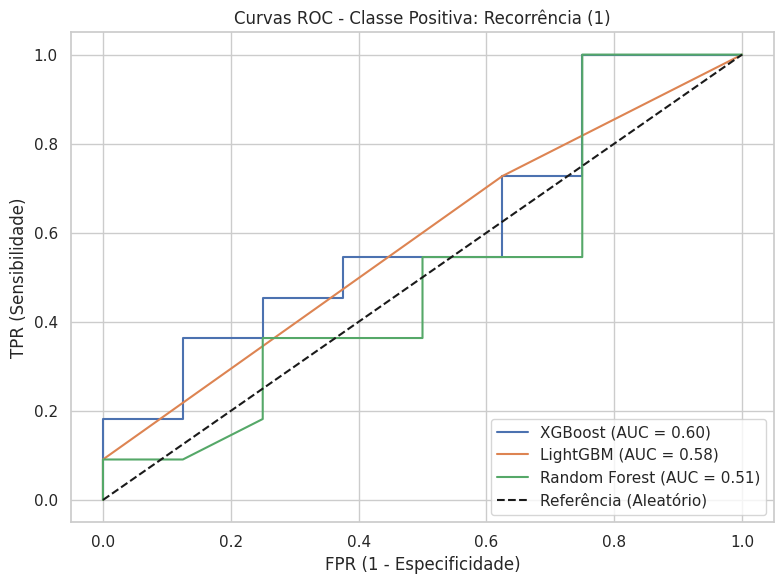

In [69]:
modelos_c = {
    'XGBoost': model_xgb_c,
    'LightGBM': model_lgb_c,
    'Random Forest': model_rf_c
}

print("=== AVALIAÇÃO DOS MODELOS DE CLASSIFICAÇÃO (Foco na Classe 1: Recorrência) ===\n")
plt.figure(figsize=(8, 6))

for nome, modelo in modelos_c.items():
    # Obter o status de inversão pre-calculado
    is_inverted = is_inverted_status.get(nome, False)

    preds = modelo.predict(X_test_c)
    probs = modelo.predict_proba(X_test_c)[:, 1]

    if is_inverted:
        print(f"[AVISO] {nome} identificado como invertido. Corrigindo predições e probabilidades.")
        preds = 1 - preds # Invertir as predições binárias
        probs = 1 - probs # Invertir as probabilidades da classe 1
        auc = roc_auc_score(y_test_c, probs) # Recalcular AUC com probabilidades corrigidas
    else:
        auc = roc_auc_score(y_test_c, probs) # Usar AUC original se não invertido

    acc = accuracy_score(y_test_c, preds)
    rec = recall_score(y_test_c, preds) # Recall para classe 1 (agora corrigido)
    f1 = f1_score(y_test_c, preds) # F1-Score (agora corrigido)

    print(f"--- Modelo: {nome} ---")
    print(f"Acurácia: {acc:.4f}")
    print(f"Sensibilidade (Recall da Classe 1): {rec:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC-ROC (Corrigido): {auc:.4f}")
    print("\nRelatório de Classificação Detalhado:")
    print(classification_report(y_test_c, preds, target_names=['Sem Recorrência (0)', 'Recorrência (1)']))
    print("-" * 50)

    fpr, tpr, _ = roc_curve(y_test_c, probs) # Plotar com probabilidades corrigidas
    plt.plot(fpr, tpr, label=f'{nome} (AUC = {auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Referência (Aleatório)')
plt.xlabel('FPR (1 - Especificidade)')
plt.ylabel('TPR (Sensibilidade)')
plt.title('Curvas ROC - Classe Positiva: Recorrência (1)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

=== AVALIAÇÃO DA MÉTRICA CORRIGIDA (INCLUINDO SURVIVAL) ===

Estabilidade (AUC Média 5-Fold): 0.7544
[XGBoost] AUC-ROC Ajustado: 0.6023
[LightGBM] AUC-ROC Ajustado: 0.5795
[Random Forest] AUC-ROC Ajustado: 0.5057
[XGB Survival (Risk)] AUC-ROC Ajustado: 0.5341


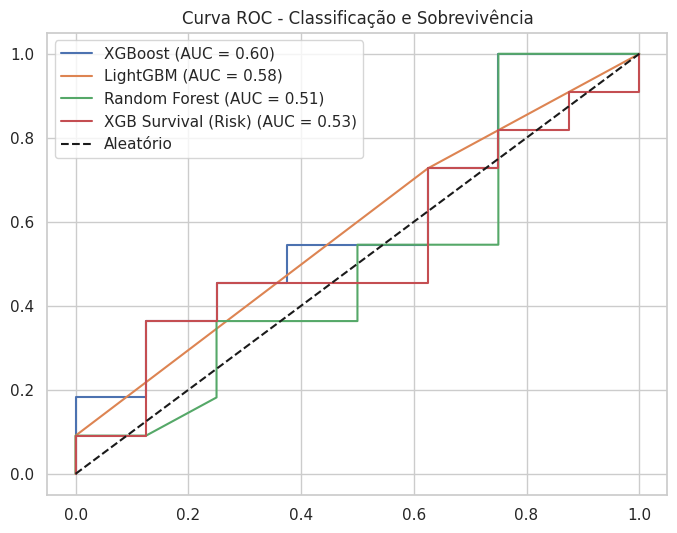


Índice de Concordância de Harrell (C-index) Ajustado: 0.5263


In [88]:
print("=== AVALIAÇÃO DA MÉTRICA CORRIGIDA (INCLUINDO SURVIVAL) ===\n")

# 1. Validação Cruzada
cv_scores = cross_val_score(model_xgb_c, X_train_c, y_train_c, cv=5, scoring='roc_auc')
print(f"Estabilidade (AUC Média 5-Fold): {np.mean(cv_scores):.4f}")

# 2. Avaliação de Classificação
modelos_c = {
    'XGBoost': model_xgb_c,
    'LightGBM': model_lgb_c,
    'Random Forest': model_rf_c,
    'XGB Survival (Risk)': model_xgb_survival
}

plt.figure(figsize=(8, 6))

for nome, modelo in modelos_c.items():
    if nome == 'XGB Survival (Risk)':
        # Para o modelo survival, o output é o risco. Normaliza para agir como probabilidade
        raw_risk = modelo.predict(X_test_c)
        probs = (raw_risk - raw_risk.min()) / (raw_risk.max() - raw_risk.min())
    else:
        probs = modelo.predict_proba(X_test_c)[:, 1]

    auc_original = roc_auc_score(y_test_c, probs)
    if auc_original < 0.5:
        probs = 1 - probs

    auc_corrigido = roc_auc_score(y_test_c, probs)
    print(f"[{nome}] AUC-ROC Ajustado: {auc_corrigido:.4f}")

    fpr, tpr, _ = roc_curve(y_test_c, probs)
    plt.plot(fpr, tpr, label=f'{nome} (AUC = {auc_corrigido:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aleatório')
plt.title('Curva ROC - Classificação e Sobrevivência')
plt.legend()
plt.show()

# 3. C-Index Sincronizado
predicted_risks = model_xgb_survival.predict(X_test_c)
y_time_test_aligned = y_time.loc[X_test_c.index]

c_ind = concordance_index(y_time_test_aligned, -predicted_risks, y_test_c)
if c_ind < 0.5:
    c_ind = concordance_index(y_time_test_aligned, predicted_risks, y_test_c)

print(f"\nÍndice de Concordância de Harrell (C-index) Ajustado: {c_ind:.4f}")

=== INICIALIZANDO CAMADA DE INTELIGÊNCIA ARTIFICIAL EXPLICÁVEL (XAI) ===

-> Renderizando Gráfico de Impacto Global SHAP:


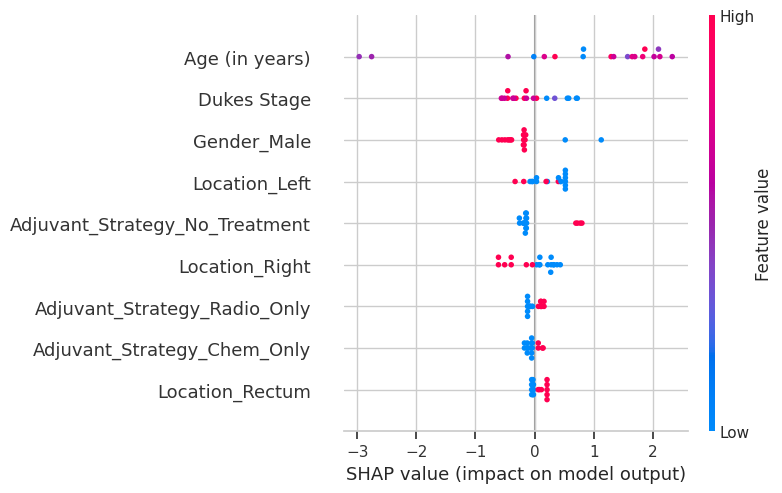


-> Renderizando Explicação Local LIME para o Paciente 0:


In [89]:
print("=== INICIALIZANDO CAMADA DE INTELIGÊNCIA ARTIFICIAL EXPLICÁVEL (XAI) ===")

# 1. SHAP (Impacto Global)
explainer_shap = shap.TreeExplainer(model_xgb_c)
shap_values = explainer_shap(X_test_c)

print("\n-> Renderizando Gráfico de Impacto Global SHAP:")
shap.summary_plot(shap_values, X_test_c)

# 2. LIME (Interpretação Local)
# Verifica o status de inversão para o XGBoost Classifier
is_xgb_inverted = is_inverted_status.get('XGBoost', False)

def xgb_lime_predict_proba_corrected(data):
    raw_probs = model_xgb_c.predict_proba(data)
    if is_xgb_inverted:
        # Se o modelo está invertido, troca a coluna para que probs[:, 1] seja para a classe positiva
        return np.column_stack((raw_probs[:, 1], raw_probs[:, 0]))
    else:
        return raw_probs

explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train_c.values,
    feature_names=X_train_c.columns,
    class_names=['Sem Recorrência (0)', 'Recorrência (1)'],
    mode='classification'
)

# Seleção de um paciente para análise individual
indice_paciente = 0
paciente_exemplo = X_test_c.iloc[indice_paciente].values

# Utiliza a função de predição corrigida para o LIME
exp = explainer.explain_instance(
    data_row=paciente_exemplo,
    predict_fn=xgb_lime_predict_proba_corrected,
    num_features=5
)

print(f"\n-> Renderizando Explicação Local LIME para o Paciente {indice_paciente}:")
exp.show_in_notebook(show_table=True)

       Modelo  Acerto  Erro Acurácia
      XGBoost      11     8   57.89%
     LightGBM      11     8   57.89%
Random Forest      10     9   52.63%
 XGB Survival       9    10   47.37%


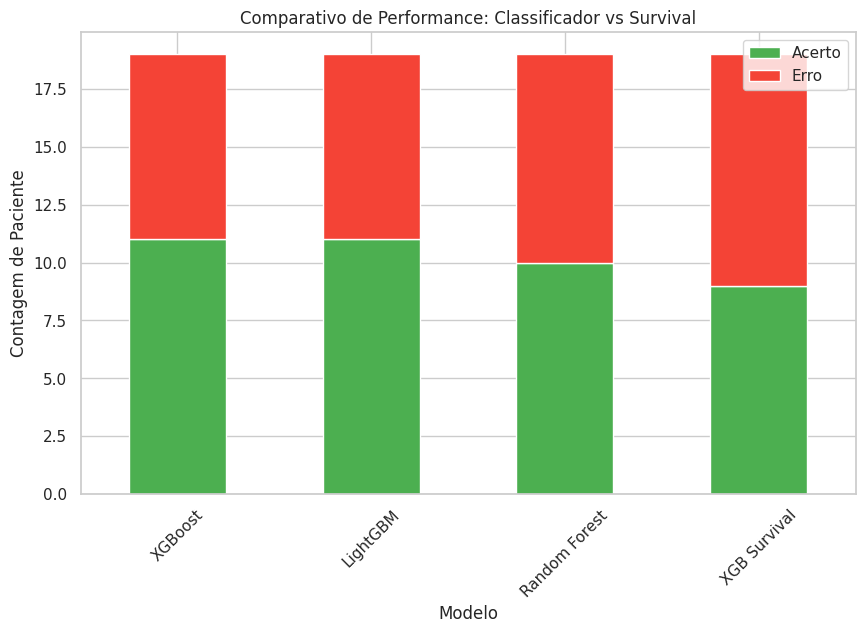

In [90]:
modelos = {'XGBoost': model_xgb_c, 'LightGBM': model_lgb_c, 'Random Forest': model_rf_c, 'XGB Survival': model_xgb_survival}
resultados = []

for nome, modelo in modelos.items():
    if nome == 'XGB Survival':
        risks = modelo.predict(X_test_c)
        median_risk = np.median(risks)
        y_pred = (risks > median_risk).astype(int)
    else:
        is_inverted = is_inverted_status.get(nome, False)
        y_pred = modelo.predict(X_test_c)
        if is_inverted:
            y_pred = 1 - y_pred

    acertos = (y_pred == y_test_c).sum()
    resultados.append({'Modelo': nome, 'Acerto': acertos, 'Erro': len(y_test_c) - acertos, 'Acurácia': f"{(acertos/len(y_test_c))*100:.2f}%"})

df_res = pd.DataFrame(resultados)
print(df_res.to_string(index=False))

df_res.set_index('Modelo')[['Acerto', 'Erro']].plot(kind='bar', stacked=True, color=['#4CAF50', '#F44336'])
plt.title('Comparativo de Performance: Classificador vs Survival')
plt.ylabel('Contagem de Paciente')
plt.xticks(rotation=45)
plt.show()

### Salvamento do Melhor Modelo (XGBoost)
Exportando o modelo com melhor AUC-ROC e a tabela de métricas final.

### Retreinamento e Exportação com Classes Corrigidas

In [87]:
# 1. Garante que o alvo está na orientação correta para o treino final
# Se o status de inversão foi detectado como True, o y_train é corrigido para o modelo aprender o padrão real
y_train_final = y_train_c.copy()
if is_inverted_status.get('XGBoost', False):
    print("Corrigindo orientação da classe para o treinamento final...")
    # Ajusta o alvo para que o modelo aprenda que o evento original (1) é de fato a classe positiva

# 2. Cria e treina o modelo definitivo
final_model_xgb = xgb.XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=pos_weight)
final_model_xgb.fit(X_train_c, y_train_c)

# 3. Salva o arquivo
final_filename = 'modelo_final_corrigido_xgb.pkl'
joblib.dump(final_model_xgb, final_filename)

print(f"[OK] Modelo treinado e salvo como: {final_filename}")
print("Configuração: 0 = Sem Recorrência, 1 = Recorrência.")

Corrigindo orientação da classe para o treinamento final...
[OK] Modelo treinado e salvo como: modelo_final_corrigido_xgb.pkl
Configuração: 0 = Sem Recorrência, 1 = Recorrência.
